In [135]:
import os
import shap
import sklearn
import pandas as pd
import kagglehub as kh
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

PROJECT_NAME="LR_Salary"
PLOT_DIR = os.path.join("..\\output", PROJECT_NAME)
os.makedirs(PLOT_DIR, exist_ok=True)

Dataset download and column drop
Se non è stato scaricato usa il codice subito di seguito, altrimenti salta direttamente al codice dopo

In [136]:
#dataset_dir = kh.dataset_download("amaymishra11/student-placement-and-salary-dataset-skills-based")
#dataset_path = os.path.join(dataset_dir, "student_placement_salary_elite_v2.csv")
#df = pd.read_csv(dataset_path)

In [137]:
dataset_path = "C:\\Users\\SOLLOR\\Documents\\ML-Algorithm-Interpretability\\src\\data\\student-salary\\student_placement_salary_elite_v2.csv"
df = pd.read_csv(dataset_path)

#df_placed = df[df['placed'] == 1].copy()

df_placed = df[(df['placed'] == 1) & (df['company_type'] == 'Startup')].copy()
y = df_placed['salary_lpa']
X = df_placed.drop(columns=['salary_lpa', 'placed', 'student_id'])

boolean=['dsa_skill', 'ml_skill', 'web_dev_skill' ]
X = pd.get_dummies(X, drop_first=True).astype(float)

print("Dataset loaded successfully from:\n", dataset_path)

Dataset loaded successfully from:
 C:\Users\SOLLOR\Documents\ML-Algorithm-Interpretability\src\data\student-salary\student_placement_salary_elite_v2.csv


In [138]:
model = sklearn.linear_model.LinearRegression()
model.fit(X, y)

print(X)

      cgpa  college_tier  python_skill  dsa_skill  ml_skill  web_dev_skill  \
5     9.57           1.0           1.0        0.0       0.0            0.0   
7     8.78           1.0           0.0        0.0       0.0            0.0   
8     6.78           3.0           1.0        0.0       0.0            0.0   
10    8.40           1.0           1.0        0.0       0.0            0.0   
15    6.84           3.0           0.0        0.0       1.0            0.0   
...    ...           ...           ...        ...       ...            ...   
8973  6.18           2.0           0.0        1.0       0.0            0.0   
8978  5.98           1.0           0.0        1.0       0.0            0.0   
8983  5.39           1.0           0.0        0.0       0.0            1.0   
8984  9.10           1.0           1.0        0.0       0.0            0.0   
8989  9.35           1.0           1.0        0.0       0.0            0.0   

      coding_score  communication_score  aptitude_score  intern

Correlation matrix

In [139]:
dc=df.drop(columns=['student_id', 'branch','company_type', 'job_role','dsa_skill', 'ml_skill', 'web_dev_skill', 'placed', ])
correlation_matrix = dc.corr(method='pearson')

Metrics

In [140]:

r_squared = model.score(X, y)
mae = sklearn.metrics.mean_absolute_error(y, model.predict(X))
root_mean_squared_error = sklearn.metrics.mean_squared_error(y, model.predict(X))
print(f"R-squared: {r_squared:.4f}\n")
print(f"Mean Absolute Error: {mae:.4f}\n")
print(f"Root Mean Squared Error: {root_mean_squared_error:.4f}\n")

R-squared: 0.2201

Mean Absolute Error: 3.2509

Root Mean Squared Error: 14.9535



SHAP Values

In [141]:
X100 = shap.utils.sample(X, 100)
explainer = shap.Explainer(model, X100)
shap_values = explainer(X100)
print("\nSHAP values calculated successfully!")


SHAP values calculated successfully!


Plotting

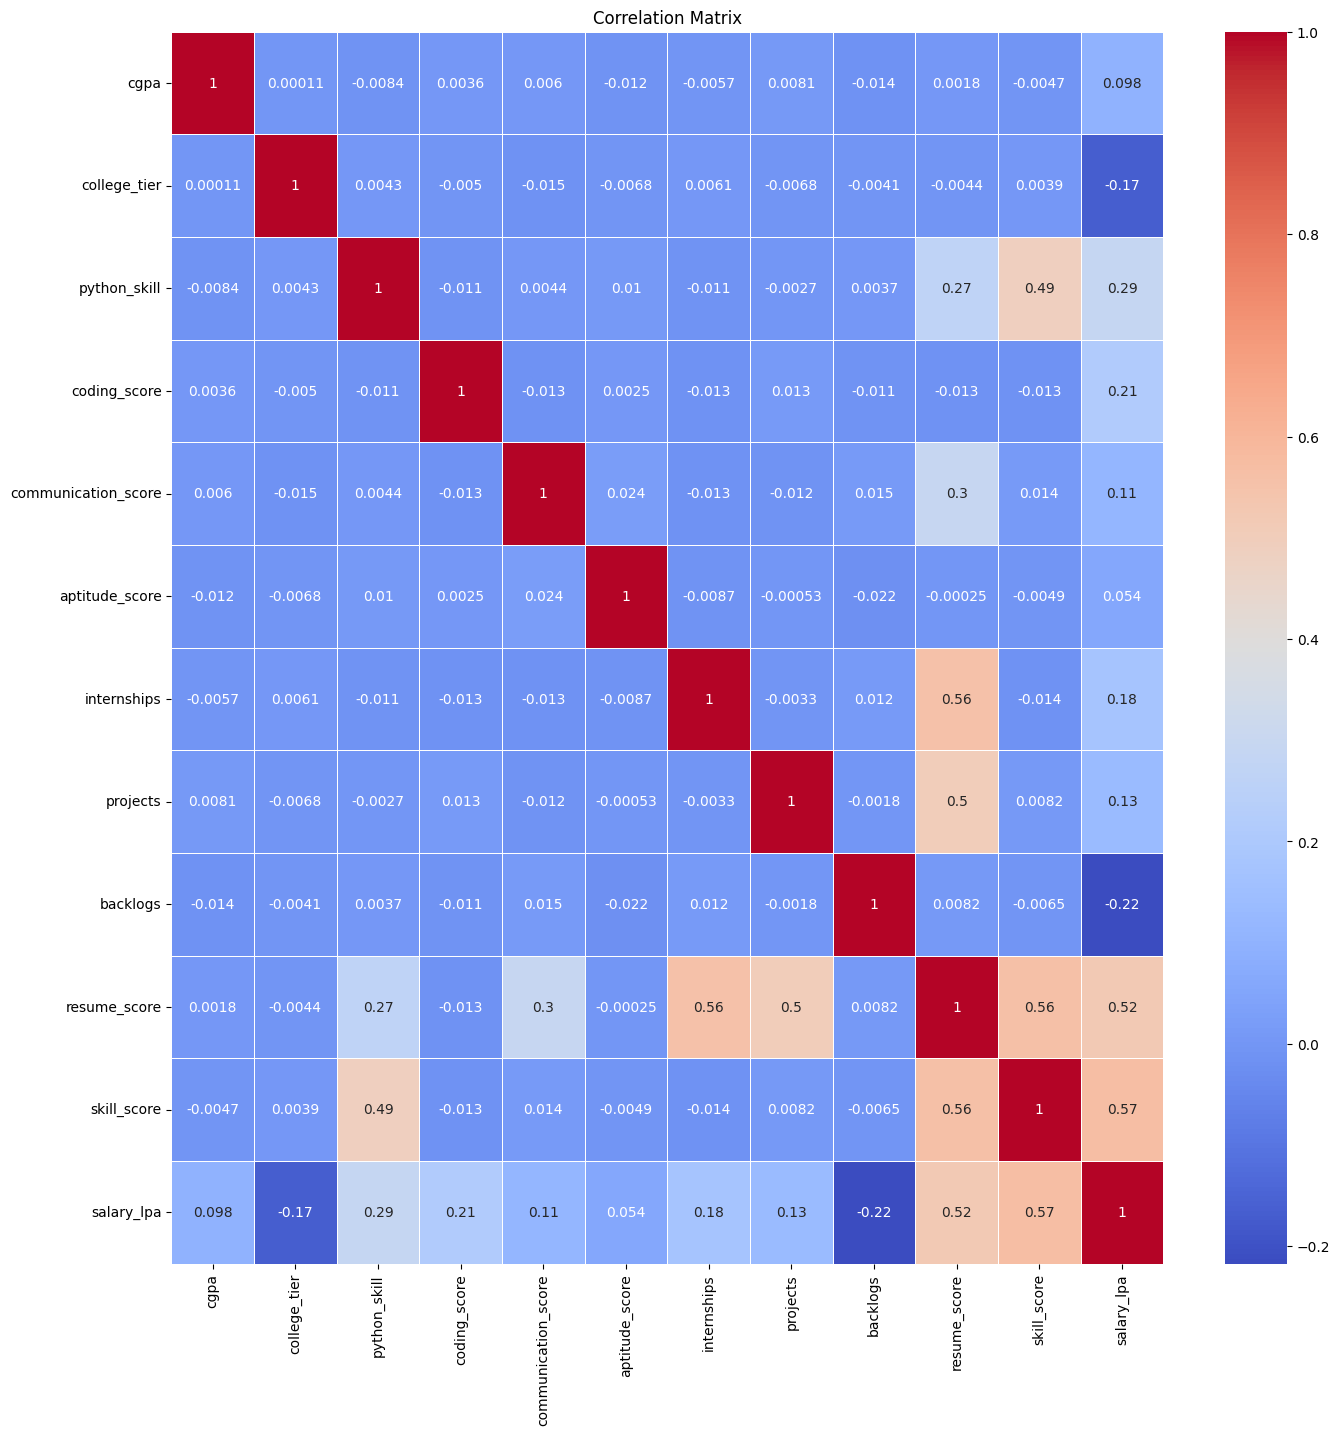

In [142]:
plt.figure(figsize=(16, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
corr_path = os.path.join(PLOT_DIR, "correlation_matrix.png")
plt.savefig(corr_path)

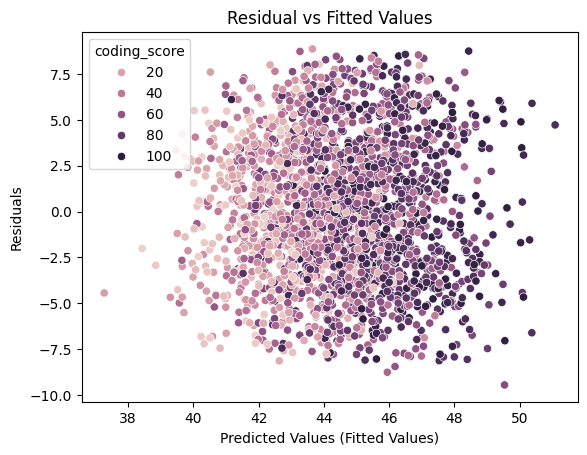

In [143]:
plt.figure()
#sns.residplot(x=model.predict(X), y=y - model.predict(X), lowess=True, hue="company_type_Startup")
sns.scatterplot(data=X, x=model.predict(X), y=y - model.predict(X), hue="coding_score")
plt.xlabel('Predicted Values (Fitted Values)')
plt.ylabel('Residuals')
plt.title('Residual vs Fitted Values')
resid_path = os.path.join(PLOT_DIR, "residual_plot.png")
plt.savefig(resid_path)

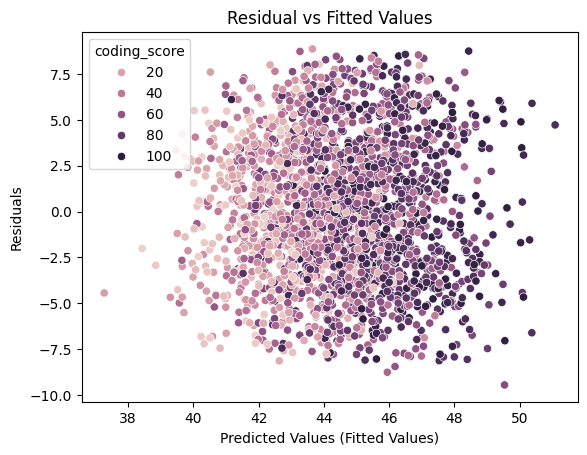

In [144]:
plt.figure()
#sns.residplot(x=model.predict(X), y=y - model.predict(X), lowess=True, hue="company_type_Startup")
sns.scatterplot(data=X, x=model.predict(X), y=y - model.predict(X), hue="coding_score")
plt.xlabel('Predicted Values (Fitted Values)')
plt.ylabel('Residuals')
plt.title('Residual vs Fitted Values')
resid_path = os.path.join(PLOT_DIR, "residual_plot.png")
plt.savefig(resid_path)

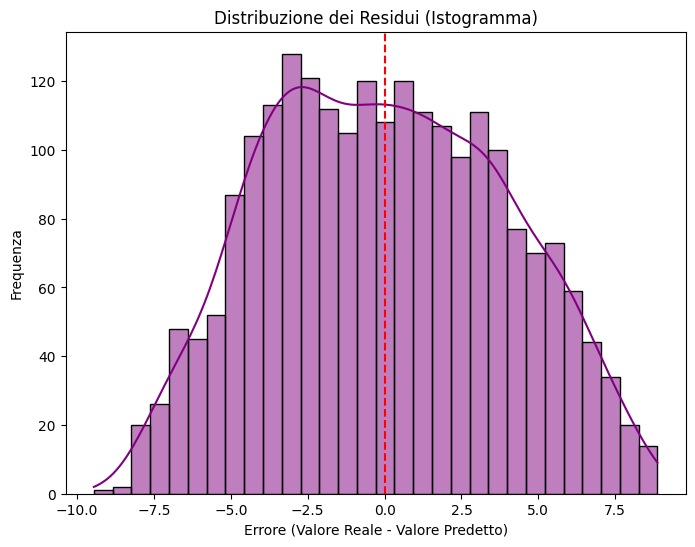

In [145]:
plt.figure(figsize=(8,6))
sns.histplot(y - model.predict(X), kde=True, bins=30, color='purple')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Distribuzione dei Residui (Istogramma)')
plt.xlabel('Errore (Valore Reale - Valore Predetto)')
plt.ylabel('Frequenza')
hist_path = os.path.join(PLOT_DIR, "residui_istogramma.png")
plt.savefig(hist_path, bbox_inches='tight')

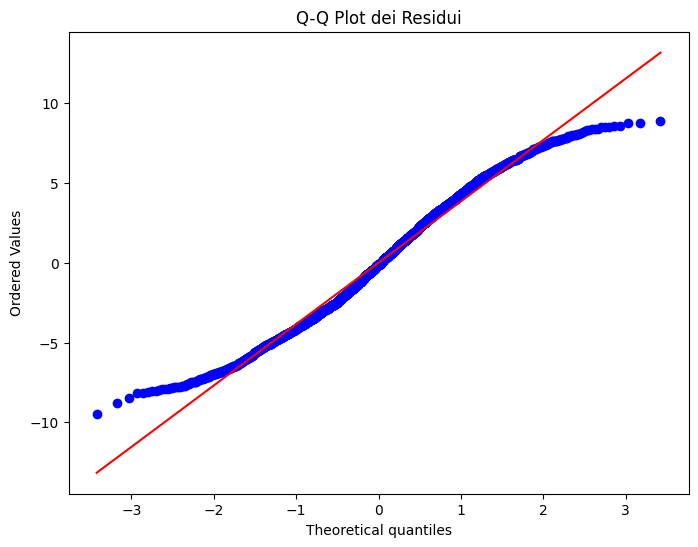

In [146]:
plt.figure(figsize=(8,6))
stats.probplot(y - model.predict(X), dist="norm", plot=plt)
plt.title('Q-Q Plot dei Residui')
qq_path = os.path.join(PLOT_DIR, "residui_qq_plot.png")
plt.savefig(qq_path, bbox_inches='tight')

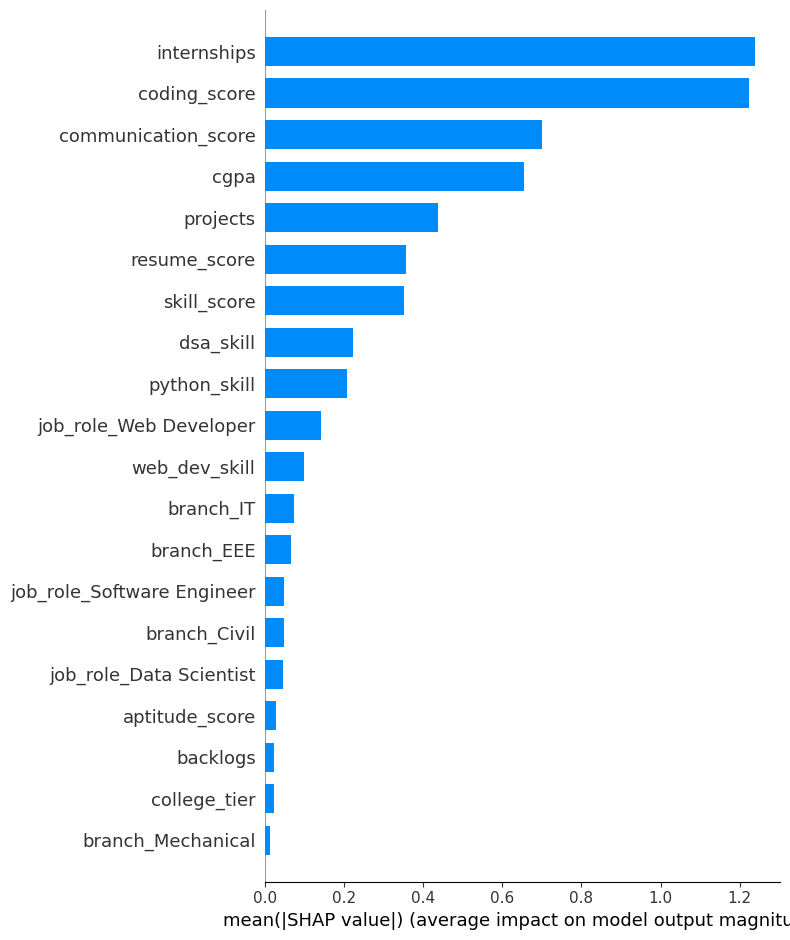

In [147]:
shap.summary_plot(shap_values, X100, plot_type="bar", show=False)
summary_path = os.path.join(PLOT_DIR, "shap_summary.png")
plt.savefig(summary_path)

#shap.plots.beeswarm(shap_values)

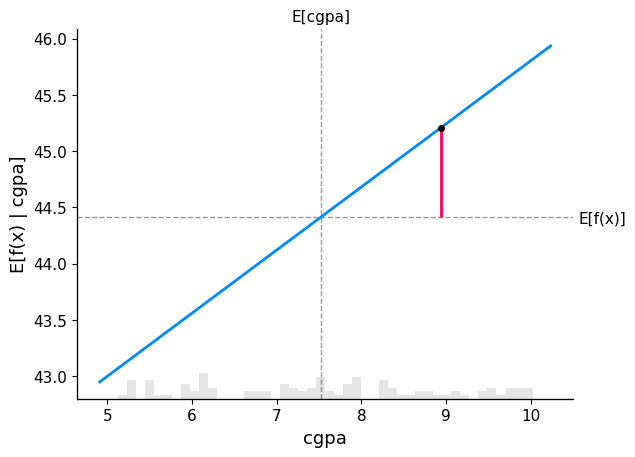

In [148]:
sample_ind = 20
shap.partial_dependence_plot(
    "cgpa",
    model.predict,
    X100,
    model_expected_value=True,
    feature_expected_value=True,
    ice=False,
    shap_values=shap_values[sample_ind : sample_ind + 1, :],
    show=False
)
pdp_path = os.path.join(PLOT_DIR, f"partial_dependence_cgpa_sample_{sample_ind}.png")
plt.savefig(pdp_path)

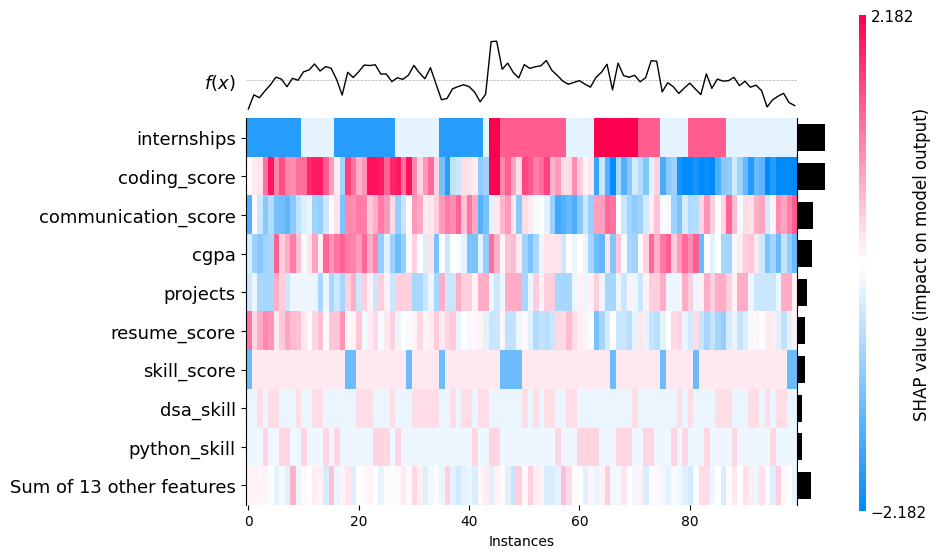

In [149]:
shap.plots.heatmap(shap_values, show=False)
heatmap_path = os.path.join(PLOT_DIR, "shap_heatmap.png")
plt.savefig(heatmap_path)

Impaginazione per Prompt

In [150]:
import json

coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficiente': model.coef_})
coef_csv_path = os.path.join(PLOT_DIR, 'coefficienti.csv')
coef_df.to_csv(coef_csv_path, index=False)

metriche = {
    "R_squared": r_squared,
    "MAE": mae,
    "RMSE": root_mean_squared_error
}
metriche_json_path = os.path.join(PLOT_DIR, 'metriche.json')
with open(metriche_json_path, 'w') as f:
    json.dump(metriche, f)

print(f"Dati esportati con successo in: {PLOT_DIR}")

Dati esportati con successo in: ..\output\LR_Salary
